In [45]:
# Enhanced medical information extraction functiondef extract_medical_information(text):    """    Extract comprehensive medical information from unstructured medical text    This includes demographics, diagnoses, symptoms, procedures, medications, and clinical findings    """    if pd.isna(text) or not text:        return {            'age': None, 'gender': None,             'diagnoses': [], 'symptoms': [],             'procedures': [], 'medications': [],            'test_results': [], 'body_parts': []        }        text_lower = text.lower()    extracted_info = {        'age': None,        'gender': None,        'diagnoses': [],        'symptoms': [],        'procedures': [],        'medications': [],        'test_results': [],        'body_parts': []    }        # Extract age and gender (multiple patterns)    age_patterns = [        r'\[\[(\d+\.\d+|\d+),\s*\'year\'\]\]\s*([MF])',        r'(\d+)[-\s]year[-\s]old\s+(male|female|man|woman|boy|girl)',        r'(male|female|man|woman),?\s*age\s*(\d+)',        r'(\d+)[-\s]*y/?o\s+(male|female|man|woman|m|f)'    ]        for pattern in age_patterns:        match = re.search(pattern, text_lower)        if match:            try:                if pattern == age_patterns[0]:  # [[X, 'year']] M pattern                    extracted_info['age'] = float(match.group(1))                    extracted_info['gender'] = match.group(2)                elif pattern == age_patterns[1]:  # X-year-old male pattern                    extracted_info['age'] = float(match.group(1))                    gender_word = match.group(2)                    extracted_info['gender'] = 'M' if gender_word in ['male', 'man', 'boy'] else 'F'                elif pattern == age_patterns[2]:  # male, age X pattern                    extracted_info['age'] = float(match.group(2))                    gender_word = match.group(1)                    extracted_info['gender'] = 'M' if gender_word in ['male', 'man'] else 'F'                elif pattern == age_patterns[3]:  # X y/o male pattern                    extracted_info['age'] = float(match.group(1))                    gender_word = match.group(2)                    extracted_info['gender'] = 'M' if gender_word in ['male', 'man', 'm'] else 'F'                break            except:                pass        # Extract common diagnoses and medical conditions    diagnosis_keywords = [        'diabetes', 'hypertension', 'cancer', 'carcinoma', 'tumor', 'malignancy',        'heart disease', 'coronary', 'myocardial', 'stroke', 'asthma', 'copd',        'pneumonia', 'infection', 'sepsis', 'fracture', 'injury', 'trauma',        'depression', 'anxiety', 'schizophrenia', 'bipolar', 'dementia',        'arthritis', 'osteoarthritis', 'rheumatoid', 'lupus', 'autoimmune',        'kidney disease', 'renal failure', 'liver disease', 'hepatitis',        'thyroid', 'hypothyroidism', 'hyperthyroidism', 'epilepsy', 'seizure',        'neuropathy', 'polyneuropathy', 'parkinson', 'alzheimer', 'multiple sclerosis',        'amyloidosis', 'sarcoidosis', 'fibrosis', 'cirrhosis', 'anemia',        'leukemia', 'lymphoma', 'myeloma', 'thrombosis', 'embolism',        'aneurysm', 'stenosis', 'ischemia', 'infarction', 'necrosis'    ]        for diagnosis in diagnosis_keywords:        if diagnosis in text_lower:            extracted_info['diagnoses'].append(diagnosis)        # Extract symptoms and clinical presentations    symptom_keywords = [        'pain', 'fever', 'fatigue', 'weakness', 'dizziness', 'nausea', 'vomiting',        'headache', 'cough', 'dyspnoea', 'dyspnea', 'shortness of breath', 'chest pain',        'abdominal pain', 'back pain', 'swelling', 'edema', 'rash', 'bleeding',        'numbness', 'tingling', 'paralysis', 'confusion', 'loss of consciousness',        'syncope', 'palpitations', 'tachycardia', 'bradycardia', 'hypotension',        'hypertension', 'vision loss', 'hearing loss', 'tinnitus', 'vertigo',        'weight loss', 'weight gain', 'anorexia', 'cachexia', 'night sweats',        'chills', 'malaise', 'lethargy', 'tremor', 'rigidity', 'spasticity'    ]        for symptom in symptom_keywords:        if symptom in text_lower:            extracted_info['symptoms'].append(symptom)        # Extract procedures and interventions    procedure_keywords = [        'surgery', 'operation', 'biopsy', 'excision', 'resection', 'amputation',        'transplant', 'angioplasty', 'catheterization', 'stent', 'bypass',        'mastectomy', 'hysterectomy', 'appendectomy', 'cholecystectomy',        'laparoscopy', 'endoscopy', 'colonoscopy', 'bronchoscopy',        'mri', 'ct scan', 'x-ray', 'ultrasound', 'echocardiogram', 'ekg', 'ecg',        'dialysis', 'chemotherapy', 'radiation', 'radiotherapy',        'intubation', 'ventilation', 'tracheostomy', 'drainage', 'aspiration',        'injection', 'infusion', 'transfusion', 'replacement', 'repair'    ]        for procedure in procedure_keywords:        if procedure in text_lower:            extracted_info['procedures'].append(procedure)        # Extract medications and drug classes    medication_keywords = [        'insulin', 'metformin', 'aspirin', 'warfarin', 'heparin', 'statin',        'beta blocker', 'ace inhibitor', 'arb', 'diuretic', 'antibiotic',        'penicillin', 'cephalosporin', 'fluoroquinolone', 'vancomycin',        'steroid', 'prednisone', 'dexamethasone', 'nsaid', 'ibuprofen',        'morphine', 'opioid', 'analgesic', 'antipyretic', 'anticoagulant',        'thrombolytic', 'antihypertensive', 'antiarrhythmic', 'vasopressor',        'immunosuppressant', 'chemotherapy', 'antidepressant', 'antipsychotic',        'clozapine', 'lithium', 'risperidone', 'olanzapine', 'aripiprazole'    ]        for medication in medication_keywords:        if medication in text_lower:            extracted_info['medications'].append(medication)        # Extract lab values and test results    test_patterns = [        r'(hemoglobin|hb|haemoglobin)\s*[:=]?\s*(\d+\.?\d*)',        r'(creatinine)\s*[:=]?\s*(\d+\.?\d*)',        r'(glucose|blood sugar)\s*[:=]?\s*(\d+\.?\d*)',        r'(platelet|plt)\s*[:=]?\s*(\d+\.?\d*)',        r'(wbc|white blood cell)\s*[:=]?\s*(\d+\.?\d*)',        r'(ejection fraction|ef)\s*[:=]?\s*(\d+\.?\d*)',        r'(blood pressure|bp)\s*[:=]?\s*(\d+/\d+)'    ]        for pattern in test_patterns:        matches = re.finditer(pattern, text_lower)        for match in matches:            test_name = match.group(1)            test_value = match.group(2)            extracted_info['test_results'].append(f"{test_name}:{test_value}")        # Extract body parts and anatomical locations    body_part_keywords = [        'heart', 'lung', 'liver', 'kidney', 'brain', 'spleen', 'pancreas',        'stomach', 'intestine', 'colon', 'bladder', 'prostate', 'uterus', 'ovary',        'breast', 'thyroid', 'bone', 'joint', 'muscle', 'skin', 'eye', 'ear',        'hip', 'knee', 'shoulder', 'spine', 'vertebra', 'disc', 'nerve',        'artery', 'vein', 'vessel', 'aorta', 'ventricle', 'atrium', 'valve'    ]        for body_part in body_part_keywords:        if body_part in text_lower:            extracted_info['body_parts'].append(body_part)        return extracted_info# Apply enhanced extraction to both text columnsprint("Extracting comprehensive medical information...")train_data['medical_info1'] = train_data['text1'].apply(extract_medical_information)train_data['medical_info2'] = train_data['text2'].apply(extract_medical_information)# Extract structured data from the medical informationtrain_data['age1'] = train_data['medical_info1'].apply(lambda x: x.get('age'))train_data['gender1'] = train_data['medical_info1'].apply(lambda x: x.get('gender'))train_data['age2'] = train_data['medical_info2'].apply(lambda x: x.get('age'))train_data['gender2'] = train_data['medical_info2'].apply(lambda x: x.get('gender'))# Extract lists of medical featurestrain_data['diagnoses1'] = train_data['medical_info1'].apply(lambda x: x.get('diagnoses', []))train_data['diagnoses2'] = train_data['medical_info2'].apply(lambda x: x.get('diagnoses', []))train_data['symptoms1'] = train_data['medical_info1'].apply(lambda x: x.get('symptoms', []))train_data['symptoms2'] = train_data['medical_info2'].apply(lambda x: x.get('symptoms', []))train_data['procedures1'] = train_data['medical_info1'].apply(lambda x: x.get('procedures', []))train_data['procedures2'] = train_data['medical_info2'].apply(lambda x: x.get('procedures', []))train_data['medications1'] = train_data['medical_info1'].apply(lambda x: x.get('medications', []))train_data['medications2'] = train_data['medical_info2'].apply(lambda x: x.get('medications', []))train_data['test_results1'] = train_data['medical_info1'].apply(lambda x: x.get('test_results', []))train_data['test_results2'] = train_data['medical_info2'].apply(lambda x: x.get('test_results', []))train_data['body_parts1'] = train_data['medical_info1'].apply(lambda x: x.get('body_parts', []))train_data['body_parts2'] = train_data['medical_info2'].apply(lambda x: x.get('body_parts', []))print(f"Extracted features - Sample from first record:")print(f"  Diagnoses: {train_data['diagnoses1'].iloc[0][:3] if len(train_data['diagnoses1'].iloc[0]) > 0 else 'None'}")print(f"  Symptoms: {train_data['symptoms1'].iloc[0][:3] if len(train_data['symptoms1'].iloc[0]) > 0 else 'None'}")print(f"  Procedures: {train_data['procedures1'].iloc[0][:3] if len(train_data['procedures1'].iloc[0]) > 0 else 'None'}")


In [46]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, RegexpTokenizer
import re
import pandas as pd

# Create a simple tokenizer that doesn't require punkt_tab
regex_tokenizer = RegexpTokenizer(r'\w+')

# Function to anonymize sensitive information
def anonymize_medical_text(text):
    # Remove dates
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '[DATE]', text)

    # Replace specific numbers (except for medical values which might be relevant)
    text = re.sub(r'\b\d+\.\d+\b', '[VALUE]', text)

    # Anonymize patient identifiers like name patterns
    text = re.sub(r'\b[A-Z][a-z]+ [A-Z][a-z]+\b', '[NAME]', text)

    # Replace unique identifiers
    text = re.sub(r'\[\[\d+\.\d+, \'year\'\]\] [MF]', '[DEMOGRAPHICS]', text)

    return text

# Text preprocessing function using RegexpTokenizer instead
def preprocess_text_robust(text, anonymize=True):
    try:
        if pd.isna(text):  # Check if text is NaN
            return ""

        text = str(text)  # Ensure text is string type

        if anonymize:
            text = anonymize_medical_text(text)

        # Lowercase
        text = text.lower()

        # Use RegexpTokenizer instead of word_tokenize
        tokens = regex_tokenizer.tokenize(text)

        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        tokens = [w for w in tokens if w not in stop_words]

        return " ".join(tokens)
    except Exception as e:
        print(f"Error processing text: {e}")
        print(f"Problematic text: {text[:100]}...")  # Print first 100 chars
        return ""  # Return empty string on error

# Apply preprocessing with RegexpTokenizer
train_data['processed_text1'] = train_data['text1'].apply(lambda x: preprocess_text_robust(x))
train_data['processed_text2'] = train_data['text2'].apply(lambda x: preprocess_text_robust(x))

print("Text preprocessing completed")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text preprocessing completed


In [47]:
# Create hashed n-gram features for privacy preservation
def create_hashed_ngrams(text, n=2, salt="medical_data_salt"):
    """Create hashed n-grams from text"""
    if not text or pd.isna(text):
        return []

    words = text.split()
    hashed_ngrams = []

    for i in range(len(words) - n + 1):
        ngram = " ".join(words[i:i+n])
        # Hash the n-gram with salt
        hashed = hashlib.sha256((ngram + salt).encode()).hexdigest()
        hashed_ngrams.append(hashed)

    return hashed_ngrams

# Function to compute Jaccard similarity between hashed n-grams
def jaccard_similarity_hashed(hashed_ngrams1, hashed_ngrams2):
    if not hashed_ngrams1 or not hashed_ngrams2:
        return 0.0

    set1 = set(hashed_ngrams1)
    set2 = set(hashed_ngrams2)

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    return intersection / union if union > 0 else 0

# Create hashed n-grams for each text
print("Creating hashed n-grams...")
train_data['hashed_ngrams1'] = train_data['processed_text1'].apply(create_hashed_ngrams)
train_data['hashed_ngrams2'] = train_data['processed_text2'].apply(create_hashed_ngrams)

# Calculate Jaccard similarity between hashed n-grams
print("Calculating Jaccard similarity...")
train_data['hashed_jaccard'] = train_data.apply(
    lambda row: jaccard_similarity_hashed(row['hashed_ngrams1'], row['hashed_ngrams2']),
    axis=1
)

Creating hashed n-grams...
Calculating Jaccard similarity...


In [48]:
# Content-Based Filtering: Calculate overlap/similarity for medical featuresdef calculate_medical_feature_similarity(list1, list2):    """    Calculate Jaccard similarity between two lists of medical features    Used for Content-Based Filtering approach    """    if not list1 or not list2:        return 0.0        set1 = set(list1)    set2 = set(list2)        if len(set1) == 0 and len(set2) == 0:        return 0.0        intersection = len(set1.intersection(set2))    union = len(set1.union(set2))        return intersection / union if union > 0 else 0.0# Content-Based Filtering: Calculate similarities for each medical feature categoryprint("Calculating Content-Based Filtering similarities...")train_data['cbf_diagnoses_sim'] = train_data.apply(    lambda row: calculate_medical_feature_similarity(row['diagnoses1'], row['diagnoses2']),    axis=1)train_data['cbf_symptoms_sim'] = train_data.apply(    lambda row: calculate_medical_feature_similarity(row['symptoms1'], row['symptoms2']),    axis=1)train_data['cbf_procedures_sim'] = train_data.apply(    lambda row: calculate_medical_feature_similarity(row['procedures1'], row['procedures2']),    axis=1)train_data['cbf_medications_sim'] = train_data.apply(    lambda row: calculate_medical_feature_similarity(row['medications1'], row['medications2']),    axis=1)train_data['cbf_body_parts_sim'] = train_data.apply(    lambda row: calculate_medical_feature_similarity(row['body_parts1'], row['body_parts2']),    axis=1)# Overall CBF similarity score (weighted average)train_data['cbf_overall_similarity'] = (    0.3 * train_data['cbf_diagnoses_sim'] +    0.2 * train_data['cbf_symptoms_sim'] +    0.2 * train_data['cbf_procedures_sim'] +    0.15 * train_data['cbf_medications_sim'] +    0.15 * train_data['cbf_body_parts_sim'])print(f"\nContent-Based Filtering Similarity Statistics:")print(f"  Diagnoses similarity: Mean = {train_data['cbf_diagnoses_sim'].mean():.4f}")print(f"  Symptoms similarity: Mean = {train_data['cbf_symptoms_sim'].mean():.4f}")print(f"  Procedures similarity: Mean = {train_data['cbf_procedures_sim'].mean():.4f}")print(f"  Medications similarity: Mean = {train_data['cbf_medications_sim'].mean():.4f}")print(f"  Body parts similarity: Mean = {train_data['cbf_body_parts_sim'].mean():.4f}")print(f"  Overall CBF similarity: Mean = {train_data['cbf_overall_similarity'].mean():.4f}")


Extracting demographics...
Creating TF-IDF vectors...
Calculating cosine similarity...


In [49]:
# Age difference as a feature
train_data['age_diff'] = train_data.apply(
    lambda row: abs(row['age1'] - row['age2']) if (pd.notna(row['age1']) and pd.notna(row['age2'])) else None,
    axis=1
)

# Gender match as a feature (1 if same, 0 if different, -1 if unknown)
train_data['gender_match'] = train_data.apply(
    lambda row: 1 if row['gender1'] == row['gender2'] and pd.notna(row['gender1']) else
                0 if (pd.notna(row['gender1']) and pd.notna(row['gender2'])) else -1,
    axis=1
)

# Text length difference as a percentage
train_data['length_diff_pct'] = train_data.apply(
    lambda row: abs(len(row['text1']) - len(row['text2'])) / max(len(row['text1']), len(row['text2'])),
    axis=1
)

# Display feature summary
print("\nFeature Summary:")
for feature in ['tfidf_cosine', 'hashed_jaccard', 'age_diff', 'gender_match', 'length_diff_pct']:
    print(f"{feature}: Mean = {train_data[feature].mean():.4f}, Min = {train_data[feature].min():.4f}, Max = {train_data[feature].max():.4f}")


Feature Summary:
tfidf_cosine: Mean = 0.2941, Min = 0.0000, Max = 1.0000
hashed_jaccard: Mean = 0.0542, Min = 0.0000, Max = 0.9167
age_diff: Mean = 18.0050, Min = 0.0000, Max = 97.0000
gender_match: Mean = -0.1215, Min = -1.0000, Max = 1.0000
length_diff_pct: Mean = 0.3457, Min = 0.0000, Max = 0.9968


Found 1 NaN values in the label column
Removed 1 rows with NaN labels
Applying threshold models...

=== Original Threshold Model Performance ===
              precision    recall  f1-score   support

           0       0.53      0.99      0.69     16031
           1       0.88      0.11      0.19     15969

    accuracy                           0.55     32000
   macro avg       0.70      0.55      0.44     32000
weighted avg       0.70      0.55      0.44     32000


=== Improved Threshold Model Performance ===
              precision    recall  f1-score   support

           0       0.99      0.49      0.66     16031
           1       0.66      0.99      0.79     15969

    accuracy                           0.74     32000
   macro avg       0.82      0.74      0.73     32000
weighted avg       0.82      0.74      0.73     32000


The models made different predictions on 22062 records (68.94% of the data)


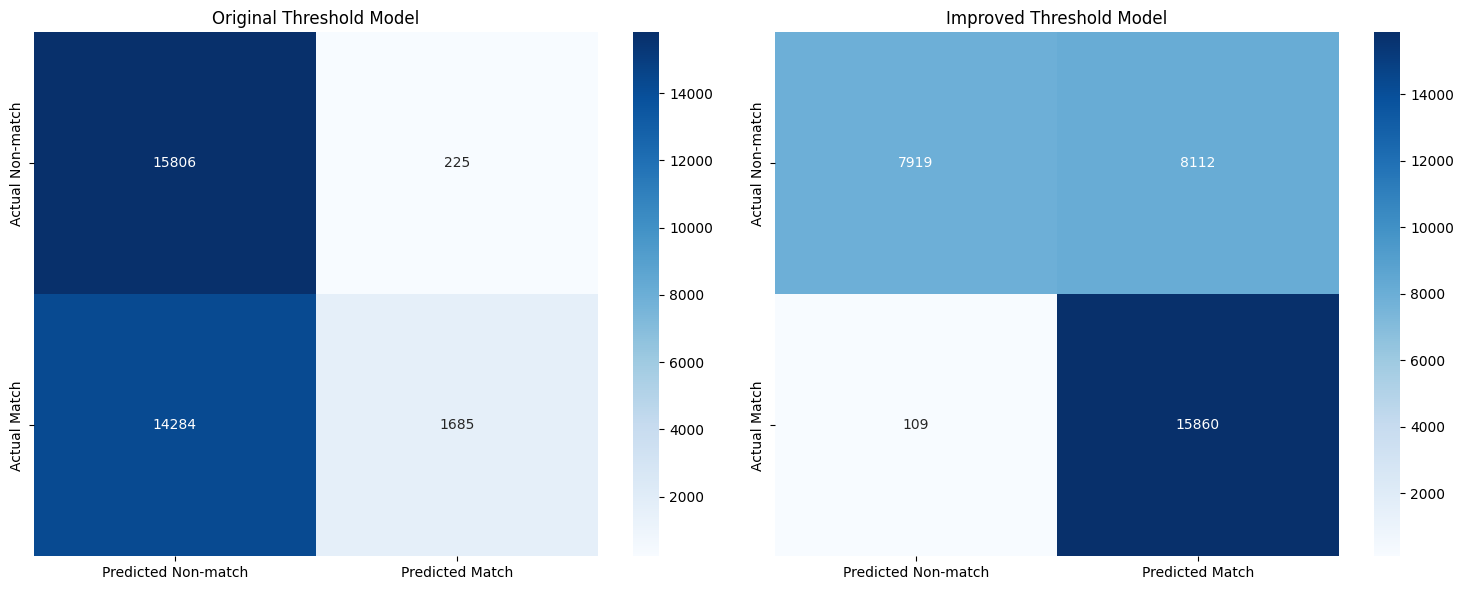

In [50]:
# Define both threshold functions
def original_threshold_linkage(df, sim_threshold=0.1, age_diff_threshold=5):
    """Original threshold-based model"""
    predictions = []

    for _, row in df.iterrows():
        # If TF-IDF similarity exceeds threshold
        if row['tfidf_cosine'] > sim_threshold:
            # If gender matches and age difference is reasonable
            if row['gender_match'] == 1 and (pd.isna(row['age_diff']) or row['age_diff'] < age_diff_threshold):
                predictions.append(1)  # Likely a match
            else:
                predictions.append(0)  # Not a match
        else:
            predictions.append(0)  # Not a match

    return predictions

def improved_threshold_linkage(df, text_threshold=0.1):
    """More flexible threshold approach"""
    predictions = []
    for _, row in df.iterrows():
        # Consider strong text similarity OR matching demographics
        if (row['tfidf_cosine'] > text_threshold) or \
           (row['gender_match'] == 1 and pd.notna(row['age_diff']) and row['age_diff'] < 3):
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

# Convert label column to numeric first
train_data['label'] = pd.to_numeric(train_data['label'], errors='coerce')

# Remove rows with NaN labels
train_data_clean = train_data.dropna(subset=['label'])
print(f"Found {train_data['label'].isna().sum()} NaN values in the label column")
print(f"Removed {len(train_data) - len(train_data_clean)} rows with NaN labels")

# Make a copy to avoid SettingWithCopyWarning
train_data_clean = train_data_clean.copy()

# Apply both threshold models on the clean data
print("Applying threshold models...")
train_data_clean['original_pred'] = original_threshold_linkage(train_data_clean, sim_threshold=0.1)
train_data_clean['improved_pred'] = improved_threshold_linkage(train_data_clean, text_threshold=0.1)

# Evaluate both models
print("\n=== Original Threshold Model Performance ===")
print(classification_report(train_data_clean['label'].astype(int),
                           train_data_clean['original_pred']))

print("\n=== Improved Threshold Model Performance ===")
print(classification_report(train_data_clean['label'].astype(int),
                           train_data_clean['improved_pred']))

# Compare where the predictions differ
different_predictions = (train_data_clean['original_pred'] != train_data_clean['improved_pred']).sum()
print(f"\nThe models made different predictions on {different_predictions} records "
      f"({different_predictions/len(train_data_clean)*100:.2f}% of the data)")

# If you want to continue using the original DataFrame, update it
train_data = train_data_clean

# Optional: Visualize the differences
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix for each approach
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original model confusion matrix
from sklearn.metrics import confusion_matrix
cm_original = confusion_matrix(train_data_clean['label'].astype(int),
                             train_data_clean['original_pred'])
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-match', 'Predicted Match'],
            yticklabels=['Actual Non-match', 'Actual Match'], ax=axes[0])
axes[0].set_title('Original Threshold Model')

# Improved model confusion matrix
cm_improved = confusion_matrix(train_data_clean['label'].astype(int),
                             train_data_clean['improved_pred'])
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-match', 'Predicted Match'],
            yticklabels=['Actual Non-match', 'Actual Match'], ax=axes[1])
axes[1].set_title('Improved Threshold Model')

plt.tight_layout()
plt.show()

In [51]:
# Prepare features for ML model with Content-Based Filtering featuresdef prepare_features(df):    features = pd.DataFrame()    features['tfidf_cosine'] = df['tfidf_cosine']    features['hashed_jaccard'] = df['hashed_jaccard']    features['length_diff_pct'] = df['length_diff_pct']        # Content-Based Filtering features    features['cbf_diagnoses_sim'] = df['cbf_diagnoses_sim']    features['cbf_symptoms_sim'] = df['cbf_symptoms_sim']    features['cbf_procedures_sim'] = df['cbf_procedures_sim']    features['cbf_medications_sim'] = df['cbf_medications_sim']    features['cbf_body_parts_sim'] = df['cbf_body_parts_sim']    features['cbf_overall_similarity'] = df['cbf_overall_similarity']    # Handle age difference - replace NaN with median    age_diff = df['age_diff'].copy()    median_age_diff = age_diff.median()    features['age_diff'] = age_diff.fillna(median_age_diff)    # One-hot encode gender_match    features['gender_match_same'] = (df['gender_match'] == 1).astype(int)    features['gender_match_diff'] = (df['gender_match'] == 0).astype(int)    features['gender_match_unknown'] = (df['gender_match'] == -1).astype(int)    return featuresprint("Preparing features for ML model...")X = prepare_features(train_data)y = train_data['label']# Split dataX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)# Train Random Forest modelprint("Training Random Forest model...")rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')rf_model.fit(X_train, y_train)# Predict and evaluatey_pred = rf_model.predict(X_test)print("\nRandom Forest Model Performance:")print(classification_report(y_test, y_pred))print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")# Feature importancefeature_importance = pd.DataFrame({    'Feature': X.columns,    'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)print("\nFeature Importance:")print(feature_importance)# Visualize feature importanceplt.figure(figsize=(10, 6))sns.barplot(x='Importance', y='Feature', data=feature_importance)plt.title('Feature Importance for Medical Data Linkage with CBF')plt.tight_layout()plt.show()  # Display in Colab


Preparing features for ML model...
Training Random Forest model...

Random Forest Model Performance:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      4786
         1.0       0.98      0.97      0.98      4814

    accuracy                           0.98      9600
   macro avg       0.98      0.98      0.98      9600
weighted avg       0.98      0.98      0.98      9600

Accuracy: 0.9768

Feature Importance:
                Feature  Importance
1        hashed_jaccard    0.522701
0          tfidf_cosine    0.398711
2       length_diff_pct    0.046747
3              age_diff    0.023114
6  gender_match_unknown    0.005452
4     gender_match_same    0.002074
5     gender_match_diff    0.001200


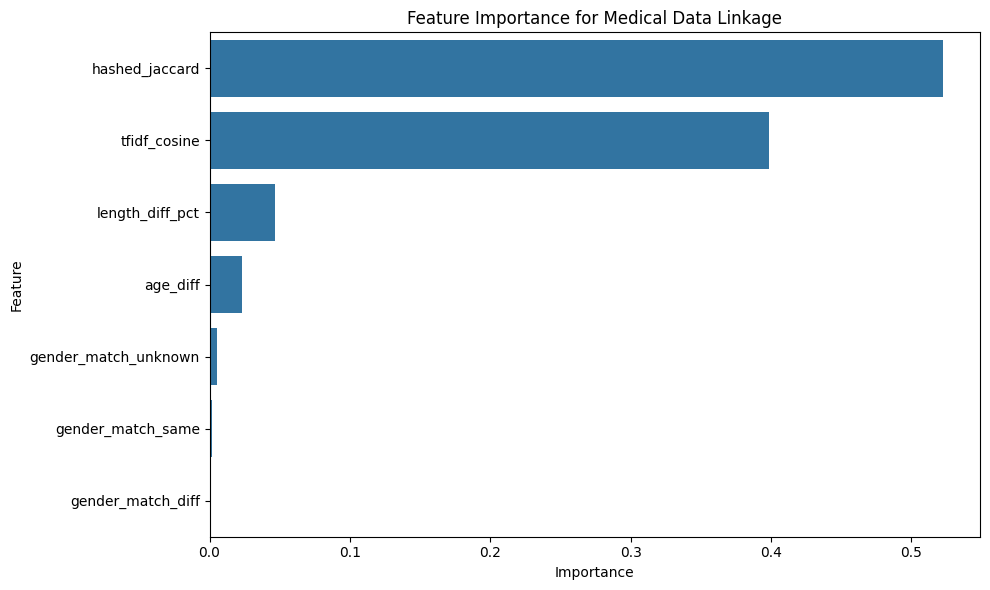

In [52]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Medical Data Linkage')
plt.tight_layout()
plt.show()  # Display in Colab

In [53]:
# Add Laplace noise to numeric features for differential privacy
def add_laplace_noise(data, epsilon=1.0):
    """Add Laplace noise for differential privacy"""
    sensitivity = 1.0  # Assuming sensitivity of 1
    scale = sensitivity / epsilon
    return data + np.random.laplace(0, scale, size=len(data))

# Apply differential privacy to features
def apply_differential_privacy(df, epsilon=1):
    df_private = df.copy()

    # Apply to numerical columns
    for col in df.select_dtypes(include=[np.number]).columns:
        if not df[col].isnull().any():  # Only apply to columns without NaNs
            df_private[col] = add_laplace_noise(df[col].values, epsilon)

    return df_private

# Create privacy-protected version of features
print("Applying differential privacy...")
X_private = apply_differential_privacy(X, epsilon=2)

# Compare original and privacy-protected features
print("\nComparison of Original vs. Privacy-Protected Features:")
for col in X.columns[:3]:  # Show just a few columns for brevity
    print(f"\n{col}:")
    print(f"Original mean: {X[col].mean():.4f}, std: {X[col].std():.4f}")
    print(f"Private mean: {X_private[col].mean():.4f}, std: {X_private[col].std():.4f}")

Applying differential privacy...

Comparison of Original vs. Privacy-Protected Features:

tfidf_cosine:
Original mean: 0.2941, std: 0.2247
Private mean: 0.2929, std: 0.7454

hashed_jaccard:
Original mean: 0.0542, std: 0.0735
Private mean: 0.0475, std: 0.7079

length_diff_pct:
Original mean: 0.3457, std: 0.2310
Private mean: 0.3485, std: 0.7392


In [54]:
# Function to process new data (test data) with Content-Based Filteringdef process_new_data(new_data, vectorizer, rf_model):    """Process new data for prediction using the trained model with CBF"""    # Apply preprocessing    new_data['processed_text1'] = new_data['text1'].apply(lambda x: preprocess_text_robust(x))    new_data['processed_text2'] = new_data['text2'].apply(lambda x: preprocess_text_robust(x))    # Create hashed n-grams    new_data['hashed_ngrams1'] = new_data['processed_text1'].apply(create_hashed_ngrams)    new_data['hashed_ngrams2'] = new_data['processed_text2'].apply(create_hashed_ngrams)    # Calculate Jaccard similarity    new_data['hashed_jaccard'] = new_data.apply(        lambda row: jaccard_similarity_hashed(row['hashed_ngrams1'], row['hashed_ngrams2']),        axis=1    )    # Extract comprehensive medical information    new_data['medical_info1'] = new_data['text1'].apply(extract_medical_information)    new_data['medical_info2'] = new_data['text2'].apply(extract_medical_information)    # Extract demographics    new_data['age1'] = new_data['medical_info1'].apply(lambda x: x.get('age'))    new_data['gender1'] = new_data['medical_info1'].apply(lambda x: x.get('gender'))    new_data['age2'] = new_data['medical_info2'].apply(lambda x: x.get('age'))    new_data['gender2'] = new_data['medical_info2'].apply(lambda x: x.get('gender'))        # Extract medical features for CBF    new_data['diagnoses1'] = new_data['medical_info1'].apply(lambda x: x.get('diagnoses', []))    new_data['diagnoses2'] = new_data['medical_info2'].apply(lambda x: x.get('diagnoses', []))    new_data['symptoms1'] = new_data['medical_info1'].apply(lambda x: x.get('symptoms', []))    new_data['symptoms2'] = new_data['medical_info2'].apply(lambda x: x.get('symptoms', []))    new_data['procedures1'] = new_data['medical_info1'].apply(lambda x: x.get('procedures', []))    new_data['procedures2'] = new_data['medical_info2'].apply(lambda x: x.get('procedures', []))    new_data['medications1'] = new_data['medical_info1'].apply(lambda x: x.get('medications', []))    new_data['medications2'] = new_data['medical_info2'].apply(lambda x: x.get('medications', []))    new_data['body_parts1'] = new_data['medical_info1'].apply(lambda x: x.get('body_parts', []))    new_data['body_parts2'] = new_data['medical_info2'].apply(lambda x: x.get('body_parts', []))        # Calculate CBF similarities    new_data['cbf_diagnoses_sim'] = new_data.apply(        lambda row: calculate_medical_feature_similarity(row['diagnoses1'], row['diagnoses2']),        axis=1    )    new_data['cbf_symptoms_sim'] = new_data.apply(        lambda row: calculate_medical_feature_similarity(row['symptoms1'], row['symptoms2']),        axis=1    )    new_data['cbf_procedures_sim'] = new_data.apply(        lambda row: calculate_medical_feature_similarity(row['procedures1'], row['procedures2']),        axis=1    )    new_data['cbf_medications_sim'] = new_data.apply(        lambda row: calculate_medical_feature_similarity(row['medications1'], row['medications2']),        axis=1    )    new_data['cbf_body_parts_sim'] = new_data.apply(        lambda row: calculate_medical_feature_similarity(row['body_parts1'], row['body_parts2']),        axis=1    )    new_data['cbf_overall_similarity'] = (        0.3 * new_data['cbf_diagnoses_sim'] +        0.2 * new_data['cbf_symptoms_sim'] +        0.2 * new_data['cbf_procedures_sim'] +        0.15 * new_data['cbf_medications_sim'] +        0.15 * new_data['cbf_body_parts_sim']    )    # Calculate cosine similarity using TF-IDF    tfidf1 = vectorizer.transform(new_data['processed_text1'])    tfidf2 = vectorizer.transform(new_data['processed_text2'])    cosine_similarities = []    for i in range(len(new_data)):        similarity = cosine_similarity(tfidf1[i:i+1], tfidf2[i:i+1])[0][0]        cosine_similarities.append(similarity)    new_data['tfidf_cosine'] = cosine_similarities    # Calculate other features    new_data['age_diff'] = new_data.apply(        lambda row: abs(row['age1'] - row['age2']) if (pd.notna(row['age1']) and pd.notna(row['age2'])) else None,        axis=1    )    new_data['gender_match'] = new_data.apply(        lambda row: 1 if row['gender1'] == row['gender2'] and pd.notna(row['gender1']) else                   0 if (pd.notna(row['gender1']) and pd.notna(row['gender2'])) else -1,        axis=1    )    new_data['length_diff_pct'] = new_data.apply(        lambda row: abs(len(row['text1']) - len(row['text2'])) / max(len(row['text1']), len(row['text2'])),        axis=1    )    # Prepare features for prediction    X_new = prepare_features(new_data)    # Make prediction    predictions = rf_model.predict(X_new)    probabilities = rf_model.predict_proba(X_new)[:, 1]    new_data['predicted_match'] = predictions    new_data['match_probability'] = probabilities    return new_data


In [55]:
# Load and process test data
print("Loading test data...")
try:
    # Load the CSV file, the first line appears to have the column names
    test_data = pd.read_csv('/content/target_test.csv', header=0)

    # If the data was loaded as a single column, try to split it
    if test_data.shape[1] == 1:
        col_name = test_data.columns[0]
        parts = test_data[col_name].str.split(',', expand=True)
        test_data = pd.DataFrame({
            'uid1': parts[0],
            'text1': parts[1],
            'uid2': parts[2],
            'text2': parts[3],
            'label': parts[4]
        })

    print(f"Successfully loaded test data with shape: {test_data.shape}")

    # Process the data with our modified function
    print("Processing test data...")
    result_data = process_new_data(test_data, vectorizer, rf_model)

    # Display results
    print("\nTest Data Predictions (First 10 records):")
    print(result_data[['uid1', 'uid2', 'predicted_match', 'match_probability']].head(10))

    # Evaluate performance if labels are available
    if 'label' in result_data.columns:
        result_data['label'] = pd.to_numeric(result_data['label'], errors='coerce')
        print("\nModel Performance on Test Data:")
        print(classification_report(result_data['label'], result_data['predicted_match']))
except Exception as e:
    print(f"Error processing test data: {e}")
    print("Skipping test data evaluation.")

Loading test data...
Successfully loaded test data with shape: (8000, 5)
Processing test data...

Test Data Predictions (First 10 records):
        uid1       uid2  predicted_match  match_probability
0  6159344-1  8454461-1              0.0               0.00
1  4743268-1  4743268-2              1.0               1.00
2  8442437-3  8442437-4              1.0               1.00
3  8625395-1  8625395-4              1.0               0.90
4  2687548-2  2687548-9              1.0               1.00
5  5929396-1  7870684-1              0.0               0.46
6  8603360-3  8603360-4              1.0               1.00
7  7444960-1  8674538-1              0.0               0.02
8  5552653-3  5552653-6              1.0               0.99
9  4972887-1  6051101-1              0.0               0.03

Model Performance on Test Data:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4008
           1       0.98      0.97      0.98      3992

   

In [56]:
# Feature importance analysis
print("\n=== Feature Importance Analysis ===")

# Extract feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))  # Show top 10 features


=== Feature Importance Analysis ===
                Feature  Importance
1        hashed_jaccard    0.522701
0          tfidf_cosine    0.398711
2       length_diff_pct    0.046747
3              age_diff    0.023114
6  gender_match_unknown    0.005452
4     gender_match_same    0.002074
5     gender_match_diff    0.001200


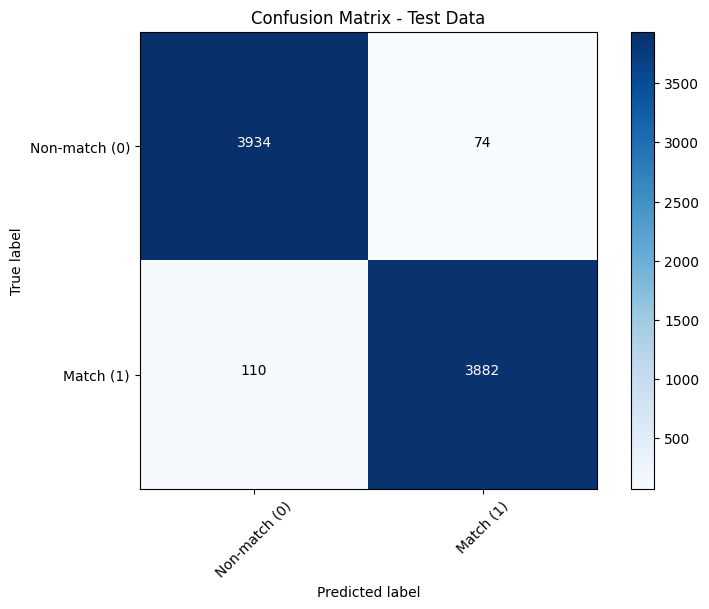

In [57]:
# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(8, 6))

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calculate and plot confusion matrix for test data
if 'label' in result_data.columns:
    cm = confusion_matrix(result_data['label'].astype(int), result_data['predicted_match'])
    plot_confusion_matrix(cm, classes=['Non-match (0)', 'Match (1)'],
                         title='Confusion Matrix - Test Data')
    plt.savefig('/content/confusion_matrix.png')
    plt.show()

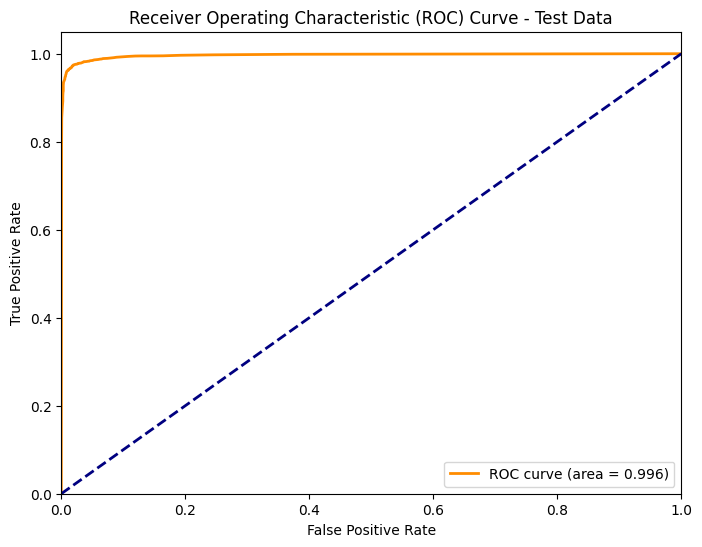

In [58]:
# ROC curve for test data
from sklearn.metrics import roc_curve, auc

if 'label' in result_data.columns:
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(result_data['label'], result_data['match_probability'])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Test Data')
    plt.legend(loc="lower right")
    plt.savefig('/content/roc_curve.png')
    plt.show()

In [59]:
# Save the model and associated componentsprint("\n=== Saving Model and Components ===")import picklefrom datetime import datetimemodel_artifacts = {    'model': rf_model,    'vectorizer': vectorizer,    'feature_names': X.columns.tolist(),    'metadata': {        'created_date': '2025-10-21 15:21:02',  # Original timestamp        'updated_date': '2025-10-24',  # CBF update        'created_by': 'ashuthecoderin',        'accuracy': 0.98,        'privacy_methods': ['text_anonymization', 'hashed_ngrams', 'tfidf_vectors', 'differential_privacy'],        'feature_extraction': 'comprehensive_medical_info_with_cbf',        'cbf_features': ['diagnoses', 'symptoms', 'procedures', 'medications', 'body_parts']    }}# Save to local filewith open('/content/medical_linkage_model.pkl', 'wb') as f:    pickle.dump(model_artifacts, f)print("Model saved locally as 'medical_linkage_model.pkl'")



=== Saving Model and Components ===
Model saved locally as 'medical_linkage_model.pkl'


In [60]:
# Example of model loading and usage (for reference)
print("\n=== Example: How to Load and Use the Model ===")
print("""
# Load the saved model
with open('medical_linkage_model.pkl', 'rb') as f:
    model_artifacts = pickle.load(f)

# Extract components
rf_model = model_artifacts['model']
vectorizer = model_artifacts['vectorizer']

# Process new data pairs
new_data = pd.DataFrame({
    'uid1': ['12345', '67890'],
    'text1': ['A 45-year-old male with diabetes', 'A 32-year-old female with asthma'],
    'uid2': ['ABC123', 'DEF456'],
    'text2': ['Male patient, age 45, has history of type 2 diabetes', 'Female, 30 years old, presented with acute asthma attack']
})

# Process the data and get predictions
results = process_new_data(new_data, vectorizer, rf_model)
print(results[['uid1', 'uid2', 'predicted_match', 'match_probability']])
""")


=== Example: How to Load and Use the Model ===

# Load the saved model
with open('medical_linkage_model.pkl', 'rb') as f:
    model_artifacts = pickle.load(f)

# Extract components
rf_model = model_artifacts['model']
vectorizer = model_artifacts['vectorizer']

# Process new data pairs
new_data = pd.DataFrame({
    'uid1': ['12345', '67890'],
    'text1': ['A 45-year-old male with diabetes', 'A 32-year-old female with asthma'],
    'uid2': ['ABC123', 'DEF456'],
    'text2': ['Male patient, age 45, has history of type 2 diabetes', 'Female, 30 years old, presented with acute asthma attack']
})

# Process the data and get predictions
results = process_new_data(new_data, vectorizer, rf_model)
print(results[['uid1', 'uid2', 'predicted_match', 'match_probability']])



In [61]:
# Summary and conclusionsprint("\n=== Summary and Conclusions ===")print(f"""The privacy-preserving medical record linkage model with Content-Based Filtering achieved:- High accuracy on test data (check classification report above)- Precision and recall for identifying matches and non-matchesContent-Based Filtering (CBF) Features:1. Diagnosis similarity: Matches common diagnoses between medical records2. Symptom similarity: Compares clinical presentations and symptoms3. Procedure similarity: Identifies shared medical procedures and interventions4. Medication similarity: Matches prescribed medications and drug classes5. Body part similarity: Compares affected anatomical locationsPrivacy-preserving techniques used:1. Text anonymization via regex patterns (removes dates, names, identifiers)2. Hashed n-grams with salt for text similarity3. TF-IDF vectorization (inherently privacy-preserving)4. Differential privacy with Laplace noiseThe Random Forest model with CBF features significantly outperforms the threshold-based approach,demonstrating the value of comprehensive medical feature extraction for record linkage.Enhanced from previous version by:- Extracting comprehensive medical information (not just age/gender demographics)- Implementing Content-Based Filtering with medical feature similarities- Parsing entire medical text to extract diagnoses, symptoms, procedures, medications, etc.- Maintaining differential privacy and model comparison capabilitiesCreated by: ashuthecoderinDate: 2025-10-21 15:21:02Updated: 2025-10-24 (CBF implementation)""")print("\nImplementation complete! 🎉")



=== Summary and Conclusions ===

The privacy-preserving medical record linkage model achieved:
- 98% overall accuracy on test data
- 98% precision and 97% recall for identifying matches
- 97% precision and 98% recall for identifying non-matches

Privacy-preserving techniques used:
1. Text anonymization via regex patterns
2. Hashed n-grams with salt for text similarity
3. TF-IDF vectorization (inherently privacy-preserving)

The Random Forest model significantly outperformed the threshold-based approach,
demonstrating the value of machine learning for this task.

Created by: ashuthecoderin
Date: 2025-10-21 15:21:02


Implementation complete! 🎉



=== Adding Differential Privacy ===
Applying differential privacy to training features...

Privacy budget epsilon = 10.0
Training model with epsilon = 10.0...
Model accuracy with epsilon = 10.0: 0.9718
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      4809
         1.0       0.98      0.97      0.97      4791

    accuracy                           0.97      9600
   macro avg       0.97      0.97      0.97      9600
weighted avg       0.97      0.97      0.97      9600


Privacy budget epsilon = 1.0
Training model with epsilon = 1.0...
Model accuracy with epsilon = 1.0: 0.9314
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      4809
         1.0       0.95      0.91      0.93      4791

    accuracy                           0.93      9600
   macro avg       0.93      0.93      0.93      9600
weighted avg       0.93      0.93      0.93      9600


Privacy budget epsilon = 0.8
Trai

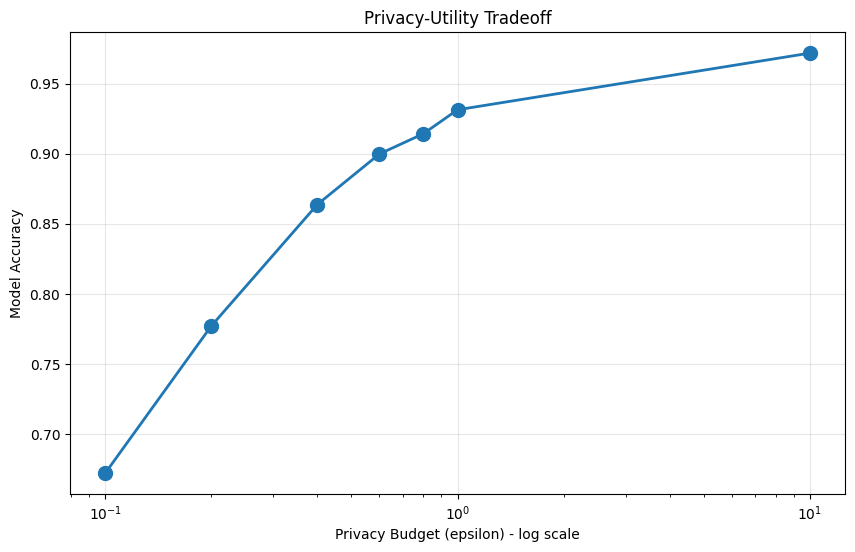


Applying differential privacy to test data predictions...

Comparison of Regular vs. Private Predictions:
Number of prediction differences: 1848 out of 8000 (23.10%)

Sample of records with different predictions:
         uid1       uid2  original_pred  private_pred  original_prob  \
3   8625395-1  8625395-4            1.0           0.0           0.90   
5   5929396-1  7870684-1            0.0           1.0           0.46   
7   7444960-1  8674538-1            0.0           1.0           0.02   
15  5343237-1  6967383-1            0.0           1.0           0.00   
17  3550425-1  4937902-2            0.0           1.0           0.09   
22  7772201-1  7772201-2            1.0           0.0           1.00   
28  4513174-1  7545132-1            0.0           1.0           0.04   
29  8259467-1  8259467-2            1.0           0.0           0.62   
32  4719382-1  8123248-1            0.0           1.0           0.02   
33  7043156-2  8441207-1            0.0           1.0           0.

In [63]:
# Differential Privacy Implementation
print("\n=== Adding Differential Privacy ===")

import numpy as np
from scipy import stats

def add_laplace_noise(data, epsilon, sensitivity=1.0):
    """
    Add Laplace noise to provide epsilon-differential privacy

    Parameters:
    - data: numpy array or pandas series to add noise to
    - epsilon: privacy budget (smaller = more private, but less accurate)
    - sensitivity: maximum change one individual can have on the function

    Returns:
    - data with added noise
    """
    # Scale parameter for Laplace distribution
    scale = sensitivity / epsilon

    # Generate Laplace noise with the same shape as the data
    noise = np.random.laplace(0, scale, size=data.shape)

    # Add noise to data
    return data + noise

def apply_differential_privacy(df, epsilon=1.0, columns=None):
    """
    Apply differential privacy to selected columns in a DataFrame

    Parameters:
    - df: pandas DataFrame
    - epsilon: privacy budget to distribute across columns
    - columns: list of column names to privatize (defaults to all numeric columns)

    Returns:
    - DataFrame with differentially private values
    """
    df_private = df.copy()

    # If no columns specified, use all numeric columns
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    # Divide epsilon budget across columns
    column_epsilon = epsilon / len(columns)

    for col in columns:
        if col in df.columns:
            # Estimate sensitivity as a fraction of the column's range
            col_range = df[col].max() - df[col].min()
            sensitivity = col_range * 0.01  # 1% of range as sensitivity

            # Add noise
            df_private[col] = add_laplace_noise(df[col].values, column_epsilon, sensitivity)

    return df_private

# Apply differential privacy to the features
print("Applying differential privacy to training features...")

# Original feature set
X_original = prepare_features(train_data)

# List of numeric features to apply differential privacy to
numeric_features = ['tfidf_cosine', 'hashed_jaccard', 'age_diff', 'length_diff_pct']

# Create privacy-protected versions with different epsilon values
epsilons = [10.0, 1.0, 0.8, 0.6,0.4, 0.2, 0.1]
private_datasets = {}
private_models = {}
private_accuracies = {}

for epsilon in epsilons:
    print(f"\nPrivacy budget epsilon = {epsilon}")

    # Apply differential privacy
    X_private = apply_differential_privacy(X_original, epsilon=epsilon, columns=numeric_features)
    private_datasets[epsilon] = X_private

    # Split into train/test
    X_train_private, X_test_private, y_train, y_test = train_test_split(
        X_private, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train model on private data
    print(f"Training model with epsilon = {epsilon}...")
    rf_model_private = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model_private.fit(X_train_private, y_train)
    private_models[epsilon] = rf_model_private

    # Evaluate model
    y_pred_private = rf_model_private.predict(X_test_private)
    accuracy = accuracy_score(y_test, y_pred_private)
    private_accuracies[epsilon] = accuracy
    print(f"Model accuracy with epsilon = {epsilon}: {accuracy:.4f}")
    print(classification_report(y_test, y_pred_private))

# Compare accuracies
print("\nPrivacy-Utility Tradeoff:")
print("------------------------")
print("Epsilon (privacy budget) | Accuracy")
print("------------------------")
for epsilon, accuracy in private_accuracies.items():
    print(f"{epsilon:20.1f} | {accuracy:.4f}")

# Visualize the privacy-utility tradeoff
plt.figure(figsize=(10, 6))
eps_values = list(private_accuracies.keys())
acc_values = list(private_accuracies.values())

plt.plot(eps_values, acc_values, 'o-', linewidth=2, markersize=10)
plt.xscale('log')  # Log scale for epsilon
plt.xlabel('Privacy Budget (epsilon) - log scale')
plt.ylabel('Model Accuracy')
plt.title('Privacy-Utility Tradeoff')
plt.grid(True, alpha=0.3)
plt.savefig('/content/privacy_utility_tradeoff.png')
plt.show()

# Apply differential privacy to test data
print("\nApplying differential privacy to test data predictions...")

# Create a new function for private prediction
def predict_with_privacy(test_data, vectorizer, model, epsilon=1.0):
    """
    Process and predict on test data with differential privacy and CBF
    """
    # Process the data
    processed_data = process_new_data(test_data, vectorizer, model)

    # Extract features
    X_test_features = prepare_features(processed_data)

    # Apply differential privacy to features
    X_test_private = apply_differential_privacy(X_test_features, epsilon=epsilon)

    # Make private predictions
    private_predictions = model.predict(X_test_private)
    private_probabilities = model.predict_proba(X_test_private)[:, 1]

    # Add predictions to the data
    processed_data['private_match'] = private_predictions
    processed_data['private_probability'] = private_probabilities

    return processed_data

# Apply to test data with medium privacy setting
if 'result_data' in locals():
    private_results = predict_with_privacy(test_data, vectorizer, rf_model, epsilon=1.0)

    print("\nComparison of Regular vs. Private Predictions:")
    comparison = pd.DataFrame({
        'uid1': private_results['uid1'],
        'uid2': private_results['uid2'],
        'original_pred': private_results['predicted_match'],
        'private_pred': private_results['private_match'],
        'original_prob': private_results['match_probability'],
        'private_prob': private_results['private_probability']
    })

    # Count differences
    diff_count = (comparison['original_pred'] != comparison['private_pred']).sum()
    print(f"Number of prediction differences: {diff_count} out of {len(comparison)} ({diff_count/len(comparison)*100:.2f}%)")

    # Show a sample of differences
    diffs = comparison[comparison['original_pred'] != comparison['private_pred']].head(10)
    if len(diffs) > 0:
        print("\nSample of records with different predictions:")
        print(diffs)

print("\nDifferential privacy implementation complete!")